In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [6]:
def lorenz(t, W, sigma, r, b):
    """ Lorenz system of ODEs
    
    Parameters
    ----------
    X : float or int
        current value of X
    Y : float or int
        current value of Y
    Z : float or int
        current value of Z
    sigma : float
        the Prandtl number
    r : float
        the Rayleigh number
    b : float
        dimensionless length scale
    
    Returns
    -------
    list of float (length 3)
        the derivative values of each of X, Y, and Z
    """
    X, Y, Z = W
    
    X_prime = -sigma*(X - Y)
    Y_prime = r*X - Y - X*Z
    Z_prime = -b*Z + X*Y
    
    return [X_prime, Y_prime, Z_prime]

In [32]:
t = 60
dt = 0.01

W_0 = [0, 1, 0]
sigma = 10
r = 28
b = 8/3

sol = solve_ivp(lorenz, [0, t], W_0, args=[sigma, r, b])

<Figure size 432x288 with 0 Axes>

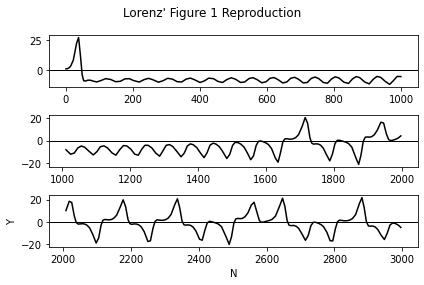

In [34]:
N = sol.t / dt
X, Y, Z = sol.y

plt.figure()
fig, axes = plt.subplots(3, 1)
fig.suptitle("Lorenz' Figure 1 Reproduction")
for i in range(3):
    index_range = (N > i*1000) & (N < (i+1)*1000)
    axes[i].axhline(y=0, color="black", lw=1)
    axes[i].plot(N[index_range], Y[index_range], color="black")
plt.xlabel("N")
plt.ylabel("Y")
plt.tight_layout()

<Figure size 432x288 with 0 Axes>

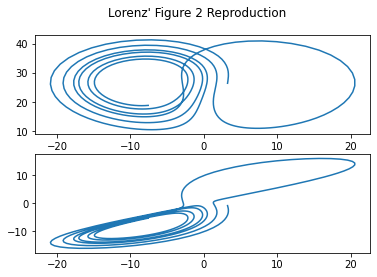

In [48]:
ts = np.linspace(0, 60, 6000)
sol = solve_ivp(lorenz, [0, 60], W_0, args=[sigma, r, b], t_eval=ts)
X, Y, Z = sol.y

plt.figure()
fig, axes = plt.subplots(2, 1)
fig.suptitle("Lorenz' Figure 2 Reproduction")

axes[0].plot(Y[1400:1900], Z[1400:1900])
axes[1].plot(Y[1400:1900], X[1400:1900])